# Human-Centred Bilingual Maize Leaf Disease Assistant

This notebook trains and evaluates the **leaf-disease screening module** that
connects to the existing Maize Detector Flask project. It does not replace the
YOLO tassel-counting model.

Supported image classes:

1. No supported disease clearly detected
2. Common rust
3. Gray leaf spot
4. Northern corn leaf blight

The model is allowed to say **uncertain**, **unsupported**, or **retake the
photo**. It is an image-assisted screening tool, not a confirmed field diagnosis
or a pesticide prescription.


## How to run

- Recommended: Kaggle or Google Colab with a free T4 GPU.
- Enable Internet access before the data-download cell.
- Run every cell from top to bottom without skipping.
- A stopped session can resume from `best_state_dict.pt` when the same output
  directory is retained.
- The final ZIP contains a TorchScript model and metadata that can be copied to
  `backend/models/disease/` in the supplied project.

The notebook exports a candidate even when quality gates fail, but the metadata
then contains `deployment_ready: false`. The Flask backend refuses that candidate
unless evaluation mode is explicitly enabled.


In [1]:
# Install small missing dependencies only. Do not reinstall torch/torchvision:
# Kaggle and Colab provide CUDA-compatible builds.
!pip -q install "scikit-learn>=1.4,<2" "seaborn>=0.13,<1" "ImageHash>=4.3,<5" "requests>=2.31,<3"



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: C:\Users\张嘉璐\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
import copy
import concurrent.futures
import hashlib
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile
from collections import Counter, defaultdict
from pathlib import Path, PurePosixPath

import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
from PIL import Image, ImageOps
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("Scikit-learn:", sklearn.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.11.5
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Scikit-learn: 1.9.0
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


## 1. Configuration and reproducibility

The repository revisions below were resolved on 24 July 2026. Dataset source,
revision, license, partition manifest, package versions, and checksums are written
to the final metadata.


In [3]:
SEED = 42
PROFILE = "quality"  # "quality" = EfficientNetV2-S; "fast" = EfficientNet-B0
IMAGE_SIZE = 224
BATCH_SIZE = 24 if PROFILE == "quality" else 32
HEAD_EPOCHS = 2
FINETUNE_EPOCHS = 12
HEAD_LR = 1e-3
FINETUNE_LR = 2e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4
# Notebook-defined Dataset classes cannot be imported reliably by spawned
# Windows worker processes. Use the main process locally; retain parallel
# workers on Kaggle/Colab/Linux.
NUM_WORKERS = 0 if os.name == "nt" else 2
TARGET_ACCEPTED_ACCURACY = 0.90
MIN_COVERAGE = 0.30
MAX_OOD_FALSE_ACCEPTANCE = 0.10
# Keep a safety margin during calibration because the untouched OOD test set
# will naturally vary. The deployment gate remains 10%; calibration targets 5%.
CALIBRATION_MAX_OOD_FALSE_ACCEPTANCE = 0.05
USER_FIELD_DATA_DIR = ""  # Optional: root/train/<class>/... and root/test/<class>/...

PLANTVILLAGE_URL = "https://github.com/spMohanty/PlantVillage-Dataset.git"
PLANTVILLAGE_REVISION = "7f7ecc7e1eaca78107e3affe7cb5abd9427e139a"
PLANTVILLAGE_SPLIT_REVISION = "a12d9d3ebb66dd0f7668e577194d6057e80f3b16"
PLANTDOC_URL = "https://github.com/pratikkayal/PlantDoc-Dataset.git"
PLANTDOC_REVISION = "5467f6012d78d1c446145d5f582da6096f852ae8"
CDS_URL = "https://osf.io/s6ru5/"
CDS_OSF_NODE = "s6ru5"
CDS_OSF_FOLDERS = {
    "train/gls": "60be29b19096b7050463f1b6",
    "train/nlb": "60be29c4cb2a5e04f868b834",
    "train/nls": "60be29d79096b704fe63f006",
    "test/gls": "60be2964cb2a5e0501690f5e",
    "test/nlb": "60be297e9096b705086437f4",
    "test/nls": "60be2994cb2a5e04fb68c454",
}

CLASS_NAMES = [
    "healthy",
    "common_rust",
    "gray_leaf_spot",
    "northern_leaf_blight",
]
DISPLAY_NAMES = {
    "healthy": "No supported disease clearly detected",
    "common_rust": "Common rust",
    "gray_leaf_spot": "Gray leaf spot",
    "northern_leaf_blight": "Northern corn leaf blight",
}
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or Path("/kaggle/working").exists()
IS_COLAB = not IS_KAGGLE and (
    "COLAB_RELEASE_TAG" in os.environ or Path("/content").exists()
)

if IS_KAGGLE:
    WORK_DIR = Path("/kaggle/working/maize_disease_agronomist")
    CACHE_DIR = Path("/tmp/maize_disease_agronomist_cache")
elif IS_COLAB:
    WORK_DIR = Path("/content/maize_disease_agronomist")
    CACHE_DIR = Path("/content/maize_disease_agronomist_cache")
else:
    WORK_DIR = Path.cwd() / "maize_disease_agronomist"
    CACHE_DIR = Path.cwd() / ".maize_disease_agronomist_cache"

OUTPUT_DIR = WORK_DIR / "outputs"
ARTIFACT_DIR = OUTPUT_DIR / "disease"
for directory in (CACHE_DIR, OUTPUT_DIR, ARTIFACT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Profile:", PROFILE)
print("Device:", DEVICE)
print("Work directory:", WORK_DIR)


Profile: quality
Device: cuda
Work directory: C:\Users\张嘉璐\Documents\Codex\2026-07-24\new-chat\work\training_run\maize_disease_agronomist


## 2. Pinned data acquisition

PlantVillage provides controlled-background images and leaf-group-aware official
splits. PlantDoc adds more difficult field-style imagery. PlantDoc `train` is used
for domain adaptation and calibration; its `test` directory remains untouched
until final evaluation. Purdue's CD&S `Dataset_Original` contributes independent
field-acquired GLS and NLB images using its official train/test split. CD&S
northern leaf spot and non-target PlantDoc classes are used only for OOD
calibration and evaluation, never as supported diagnoses.


In [4]:
def checkout_repository(url, revision, destination, sparse_paths=None):
    destination = Path(destination)
    if destination.exists() and not (destination / ".git").exists():
        shutil.rmtree(destination)
    if not destination.exists():
        subprocess.run(
            ["git", "clone", "--filter=blob:none", "--no-checkout", url, str(destination)],
            check=True,
        )
    subprocess.run(["git", "-C", str(destination), "fetch", "--depth", "1", "origin", revision], check=True)
    if sparse_paths:
        subprocess.run(["git", "-C", str(destination), "sparse-checkout", "init", "--cone"], check=True)
        subprocess.run(
            ["git", "-C", str(destination), "sparse-checkout", "set", *sparse_paths],
            check=True,
        )
    subprocess.run(["git", "-C", str(destination), "checkout", "--detach", revision], check=True)
    actual = subprocess.check_output(
        ["git", "-C", str(destination), "rev-parse", "HEAD"], text=True
    ).strip()
    if actual != revision:
        raise RuntimeError(f"Revision mismatch for {destination.name}: {actual} != {revision}")
    return destination

def materialize_windows_safe_github_archive(repository, revision, destination):
    '''Materialize a pinned GitHub tree with Windows-safe local filenames.

    PlantDoc contains URL query strings in historical filenames. Those names are
    valid Git paths but cannot be created on NTFS. Image bytes, split folders,
    the source member name, and the pinned commit are preserved in a mapping
    manifest; only the local basename is replaced with a deterministic hash.
    '''
    destination = Path(destination)
    marker = destination / ".revision"
    mapping_path = CACHE_DIR / "plantdoc_file_map.csv"
    if (
        destination.exists()
        and marker.exists()
        and marker.read_text(encoding="utf-8").strip() == revision
        and mapping_path.exists()
    ):
        return destination, mapping_path

    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True)
    archive_path = CACHE_DIR / f"PlantDoc-{revision}.zip"
    if not archive_path.exists():
        archive_url = f"https://github.com/{repository}/archive/{revision}.zip"
        urllib.request.urlretrieve(archive_url, archive_path)

    rows = []
    with zipfile.ZipFile(archive_path) as archive:
        for info in archive.infolist():
            if info.is_dir():
                continue
            member = PurePosixPath(info.filename)
            relative_parts = member.parts[1:]
            if (
                not relative_parts
                or relative_parts[0] not in {"train", "test"}
                or ".." in relative_parts
            ):
                continue
            suffix = PurePosixPath(relative_parts[-1]).suffix.lower()
            if suffix not in IMAGE_EXTENSIONS:
                continue
            safe_name = hashlib.sha256(
                "/".join(relative_parts).encode("utf-8")
            ).hexdigest()[:24] + suffix
            target = destination.joinpath(*relative_parts[:-1], safe_name)
            target.parent.mkdir(parents=True, exist_ok=True)
            content_hash = hashlib.sha256()
            with archive.open(info) as source, open(target, "wb") as sink:
                for chunk in iter(lambda: source.read(1024 * 1024), b""):
                    sink.write(chunk)
                    content_hash.update(chunk)
            rows.append(
                {
                    "source_member": "/".join(relative_parts),
                    "safe_relative_path": target.relative_to(destination).as_posix(),
                    "sha256": content_hash.hexdigest(),
                    "revision": revision,
                }
            )
    pd.DataFrame(rows).to_csv(mapping_path, index=False)
    marker.write_text(revision, encoding="utf-8")
    return destination, mapping_path

def download_cds_original(destination):
    # CD&S Dataset_Original is hosted by Purdue's public OSF record. The OSF
    # folder ids preserve its official train/test split. NLS remains an unknown
    # class and is never relabelled as one of the supported conditions.
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)
    manifest_path = destination / "manifest.json"
    def content_hash(path):
        digest = hashlib.sha256()
        with open(path, "rb") as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(chunk)
        return digest.hexdigest()

    if manifest_path.exists():
        payload = json.loads(manifest_path.read_text(encoding="utf-8"))
        valid = True
        for item in payload.get("files", []):
            path = destination / item["relative_path"]
            if not path.exists() or content_hash(path) != item["sha256"]:
                valid = False
                break
        if valid and len(payload.get("files", [])) >= 1500:
            return destination, manifest_path

    api_root = "https://api.osf.io/v2/nodes/s6ru5/files/osfstorage"
    tasks = []
    for partition, folder_id in CDS_OSF_FOLDERS.items():
        url = f"{api_root}/{folder_id}/?page[size]=100"
        while url:
            page = None
            for attempt in range(8):
                response = requests.get(url, timeout=60)
                if response.status_code == 429 or response.status_code >= 500:
                    retry_after = response.headers.get("Retry-After")
                    response.close()
                    delay = float(retry_after) if retry_after else min(60, 2 ** attempt)
                    time.sleep(delay)
                    continue
                response.raise_for_status()
                page = response.json()
                break
            if page is None:
                raise RuntimeError(f"CD&S listing retries exhausted: {folder_id}")
            for row in page["data"]:
                tasks.append((partition, row))
            url = page.get("links", {}).get("next")

    def fetch(task):
        partition, row = task
        attributes = row["attributes"]
        expected = attributes["extra"]["hashes"]["sha256"]
        target = destination / partition / attributes["name"]
        target.parent.mkdir(parents=True, exist_ok=True)
        if target.exists() and content_hash(target) == expected:
            return partition, row, target
        part = target.with_suffix(target.suffix + ".part")
        digest = hashlib.sha256()
        response = None
        for attempt in range(8):
            candidate = requests.get(
                row["links"]["download"], stream=True, timeout=120
            )
            if candidate.status_code == 429 or candidate.status_code >= 500:
                retry_after = candidate.headers.get("Retry-After")
                candidate.close()
                delay = float(retry_after) if retry_after else min(60, 2 ** attempt)
                time.sleep(delay)
                continue
            candidate.raise_for_status()
            response = candidate
            break
        if response is None:
            raise RuntimeError(f"CD&S download retries exhausted: {attributes['name']}")
        with response:
            with open(part, "wb") as handle:
                for chunk in response.iter_content(1024 * 1024):
                    if chunk:
                        handle.write(chunk)
                        digest.update(chunk)
        if digest.hexdigest() != expected:
            part.unlink(missing_ok=True)
            raise RuntimeError(f"CD&S SHA-256 mismatch: {attributes['name']}")
        os.replace(part, target)
        return partition, row, target

    rows = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=6) as executor:
        for partition, row, target in executor.map(fetch, tasks):
            attributes = row["attributes"]
            rows.append(
                {
                    "split": partition.split("/")[0],
                    "class": partition.split("/")[1],
                    "relative_path": target.relative_to(destination).as_posix(),
                    "osf_file_id": row["id"],
                    "download_url": row["links"]["download"],
                    "size": attributes["size"],
                    "sha256": attributes["extra"]["hashes"]["sha256"],
                }
            )
    rows.sort(key=lambda item: item["relative_path"])
    manifest_path.write_text(
        json.dumps(
            {
                "dataset": "CD&S Dataset_Original",
                "osf_node": CDS_OSF_NODE,
                "source": CDS_URL,
                "license": "Not specified in OSF metadata; verify before redistribution",
                "files": rows,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    return destination, manifest_path

pv_folders = {
    "Corn_(maize)___healthy": "healthy",
    "Corn_(maize)___Common_rust_": "common_rust",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "gray_leaf_spot",
    "Corn_(maize)___Northern_Leaf_Blight": "northern_leaf_blight",
}
pv_sparse_paths = [f"raw/color/{folder}" for folder in pv_folders]
PLANTVILLAGE_DIR = checkout_repository(
    PLANTVILLAGE_URL,
    PLANTVILLAGE_REVISION,
    CACHE_DIR / "PlantVillage-Dataset",
    pv_sparse_paths,
)
if os.name == "nt":
    PLANTDOC_DIR, PLANTDOC_FILE_MAP = materialize_windows_safe_github_archive(
        "pratikkayal/PlantDoc-Dataset",
        PLANTDOC_REVISION,
        CACHE_DIR / "PlantDoc-Dataset-windows-safe",
    )
else:
    PLANTDOC_DIR = checkout_repository(
        PLANTDOC_URL,
        PLANTDOC_REVISION,
        CACHE_DIR / "PlantDoc-Dataset",
    )
    PLANTDOC_FILE_MAP = None
CDS_DIR, CDS_MANIFEST = download_cds_original(
    CACHE_DIR / "CDS-Dataset-Original"
)

split_dir = CACHE_DIR / "plantvillage_splits"
split_dir.mkdir(exist_ok=True)
for split_name in ("train", "test"):
    split_path = split_dir / f"color_{split_name}.txt"
    if not split_path.exists():
        url = (
            "https://huggingface.co/datasets/mohanty/PlantVillage/resolve/"
            f"{PLANTVILLAGE_SPLIT_REVISION}/splits/color_{split_name}.txt"
        )
        urllib.request.urlretrieve(url, split_path)

print("PlantVillage:", PLANTVILLAGE_REVISION)
print("PlantDoc:", PLANTDOC_REVISION)
print("CD&S:", CDS_OSF_NODE, len(json.loads(CDS_MANIFEST.read_text())["files"]))


PlantVillage: 7f7ecc7e1eaca78107e3affe7cb5abd9427e139a
PlantDoc: 5467f6012d78d1c446145d5f582da6096f852ae8
CD&S: s6ru5 1571


In [5]:
def pv_samples(manifest_path):
    samples = []
    for text in Path(manifest_path).read_text(encoding="utf-8").splitlines():
        relative = Path(text.strip())
        class_name = pv_folders.get(relative.parent.name)
        if class_name:
            path = PLANTVILLAGE_DIR / relative
            if not path.exists():
                raise FileNotFoundError(path)
            samples.append((path, CLASS_TO_INDEX[class_name], "plantvillage"))
    return samples

def plantdoc_label(folder_name):
    text = folder_name.lower()
    if "corn" not in text:
        return None
    if "gray" in text and "spot" in text:
        return "gray_leaf_spot"
    if "rust" in text:
        return "common_rust"
    if "blight" in text:
        # PlantDoc uses the generic label "Corn leaf blight"; it does not
        # establish the Northern corn leaf blight subtype used by this model.
        # Treat it as unsupported instead of introducing unsafe label noise.
        return None
    if "healthy" in text:
        return "healthy"
    return None

def plantdoc_partition(partition):
    known, ood = [], []
    root = PLANTDOC_DIR / partition
    for path in sorted(root.rglob("*")):
        if path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        label = plantdoc_label(path.parent.name)
        if label is None:
            ood.append((path, -1, f"plantdoc_{partition}_ood"))
        else:
            known.append((path, CLASS_TO_INDEX[label], f"plantdoc_{partition}"))
    return known, ood

def cds_partition(partition):
    known, ood = [], []
    payload = json.loads(CDS_MANIFEST.read_text(encoding="utf-8"))
    label_map = {
        "gls": "gray_leaf_spot",
        "nlb": "northern_leaf_blight",
    }
    for item in payload["files"]:
        if item["split"] != partition:
            continue
        path = CDS_DIR / item["relative_path"]
        if item["class"] in label_map:
            known.append(
                (
                    path,
                    CLASS_TO_INDEX[label_map[item["class"]]],
                    f"cds_{partition}",
                )
            )
        else:
            # Northern leaf spot is deliberately unsupported.
            ood.append((path, -1, f"cds_{partition}_nls_ood"))
    return known, ood

pv_official_train = pv_samples(split_dir / "color_train.txt")
pv_internal_test = pv_samples(split_dir / "color_test.txt")
pd_train_known, pd_train_ood = plantdoc_partition("train")
pd_field_test, pd_test_ood = plantdoc_partition("test")
cds_train_known, cds_train_ood = cds_partition("train")
cds_field_test, cds_test_ood = cds_partition("test")

def three_way_split(samples, validation_size=0.15, calibration_size=0.15):
    labels = [sample[1] for sample in samples]
    train, holdout = train_test_split(
        samples,
        test_size=validation_size + calibration_size,
        random_state=SEED,
        stratify=labels,
    )
    holdout_labels = [sample[1] for sample in holdout]
    validation, calibration = train_test_split(
        holdout,
        test_size=calibration_size / (validation_size + calibration_size),
        random_state=SEED + 1,
        stratify=holdout_labels,
    )
    return train, validation, calibration

pv_train, pv_validation, pv_calibration = three_way_split(pv_official_train)
if len(pd_train_known) >= 24 and min(Counter(x[1] for x in pd_train_known).values()) >= 4:
    pd_train, pd_validation, pd_calibration = three_way_split(
        pd_train_known, validation_size=0.15, calibration_size=0.15
    )
else:
    pd_train, pd_validation, pd_calibration = pd_train_known, [], []
cds_train, cds_validation, cds_calibration = three_way_split(
    cds_train_known, validation_size=0.15, calibration_size=0.15
)

train_samples = pv_train + pd_train + cds_train
validation_samples = pv_validation + pd_validation + cds_validation
calibration_samples = pv_calibration + pd_calibration + cds_calibration
internal_test_samples = pv_internal_test
plantdoc_test_samples = pd_field_test
cds_test_samples = cds_field_test
external_test_samples = plantdoc_test_samples + cds_test_samples
ood_calibration_samples = pd_train_ood + cds_train_ood
ood_test_samples = pd_test_ood + cds_test_ood

partitions = {
    "train": train_samples,
    "validation": validation_samples,
    "calibration": calibration_samples,
    "internal_test": internal_test_samples,
    "external_field_test": external_test_samples,
    "ood_calibration": ood_calibration_samples,
    "ood_test": ood_test_samples,
}
pd.DataFrame(
    [
        {"partition": name, "samples": len(samples)}
        for name, samples in partitions.items()
    ]
)


,partition,samples
0,train,2616
1,validation,561
2,calibration,562
3,internal_test,794
4,external_field_test,523
5,ood_calibration,2447
6,ood_test,498


## 3. Leakage and partition checks

The official PlantVillage split already respects leaf grouping. The checks below
add exact file hashes and perceptual hashes across every partition. If a public
source contains a duplicate across development and final-test partitions, the
final test is preserved and the development copy is removed before training.
Every removal is recorded for auditability.


In [6]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

hash_rows = []
for partition_name, samples in partitions.items():
    for path, label, source in samples:
        with Image.open(path) as image:
            perceptual = str(imagehash.phash(ImageOps.exif_transpose(image).convert("RGB")))
        hash_rows.append(
            {
                "partition": partition_name,
                "path": str(path),
                "label": int(label),
                "source": source,
                "sha256": sha256_file(path),
                "phash": perceptual,
            }
        )
hash_frame = pd.DataFrame(hash_rows)

development = {"train", "validation", "calibration", "ood_calibration"}
final_tests = {"internal_test", "external_field_test", "ood_test"}
leak_groups = []
removal_rows = []
removal_paths = set()
for hash_column in ("sha256", "phash"):
    for hash_value, group in hash_frame.groupby(hash_column):
        seen = set(group["partition"])
        if seen.intersection(development) and seen.intersection(final_tests):
            final_partitions = sorted(seen.intersection(final_tests))
            leak_groups.append(
                {
                    "hash_type": hash_column,
                    "hash": hash_value,
                    "partitions": sorted(seen),
                    "examples": group["path"].tolist()[:4],
                }
            )
            for row in group[group["partition"].isin(development)].itertuples():
                removal_paths.add(row.path)
                removal_rows.append(
                    {
                        "hash_type": hash_column,
                        "hash": hash_value,
                        "removed_partition": row.partition,
                        "removed_path": row.path,
                        "matched_final_partitions": "|".join(final_partitions),
                    }
                )

leakage_report_path = OUTPUT_DIR / "leakage_removals.csv"
pd.DataFrame(
    removal_rows,
    columns=[
        "hash_type",
        "hash",
        "removed_partition",
        "removed_path",
        "matched_final_partitions",
    ],
).drop_duplicates().to_csv(leakage_report_path, index=False)

if removal_paths:
    for partition_name in development:
        partitions[partition_name] = [
            sample for sample in partitions[partition_name]
            if str(sample[0]) not in removal_paths
        ]
    train_samples = partitions["train"]
    validation_samples = partitions["validation"]
    calibration_samples = partitions["calibration"]
    ood_calibration_samples = partitions["ood_calibration"]
    hash_frame = hash_frame[~hash_frame["path"].isin(removal_paths)].copy()

# Re-check after preserving every final-test item and removing development copies.
leaks = []
for hash_column in ("sha256", "phash"):
    for _, group in hash_frame.groupby(hash_column):
        seen = set(group["partition"])
        if seen.intersection(development) and seen.intersection(final_tests):
            leaks.append(
                {
                    "hash_type": hash_column,
                    "partitions": sorted(seen),
                    "examples": group["path"].tolist()[:4],
                }
            )
if leaks:
    display(pd.DataFrame(leaks))
    raise RuntimeError("Leakage remains after development-set de-duplication")

manifest_path = OUTPUT_DIR / "partition_manifest.csv"
hash_frame.to_csv(manifest_path, index=False)
print("Development duplicates removed:", len(removal_paths))
print("Leakage check passed. Manifest:", manifest_path)


Development duplicates removed: 15
Leakage check passed. Manifest: C:\Users\张嘉璐\Documents\Codex\2026-07-24\new-chat\work\training_run\maize_disease_agronomist\outputs\partition_manifest.csv


## 4. Data loaders and field-oriented augmentation

Validation, calibration, and test preprocessing are identical to backend
preprocessing. Stronger training augmentation helps reduce dependence on clean
backgrounds while avoiding transformations that would destroy lesion colour.


In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.60, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(18),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.18, hue=0.04),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.10),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.5, 2.0)),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ImagePathDataset(Dataset):
    def __init__(self, samples, transform, return_path=False):
        self.samples = list(samples)
        self.targets = [item[1] for item in self.samples]
        self.transform = transform
        self.return_path = return_path

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label, _source = self.samples[index]
        with Image.open(path) as opened:
            image = ImageOps.exif_transpose(opened).convert("RGB")
            tensor = self.transform(image)
        return (tensor, label, str(path)) if self.return_path else (tensor, label)

datasets = {
    "train": ImagePathDataset(train_samples, train_transform),
    "validation": ImagePathDataset(validation_samples, eval_transform),
    "calibration": ImagePathDataset(calibration_samples, eval_transform),
    "internal_test": ImagePathDataset(internal_test_samples, eval_transform),
    "external_field_test": ImagePathDataset(external_test_samples, eval_transform),
    "plantdoc_field_test": ImagePathDataset(plantdoc_test_samples, eval_transform),
    "cds_field_test": ImagePathDataset(cds_test_samples, eval_transform),
    "ood_calibration": ImagePathDataset(ood_calibration_samples, eval_transform),
    "ood_test": ImagePathDataset(ood_test_samples, eval_transform),
}

train_counts = np.bincount(datasets["train"].targets, minlength=len(CLASS_NAMES))
sample_weights = [1.0 / max(train_counts[label], 1) for label in datasets["train"].targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}
loaders = {
    name: DataLoader(
        dataset,
        sampler=sampler if name == "train" else None,
        shuffle=False,
        **loader_options,
    )
    for name, dataset in datasets.items()
}
display(pd.DataFrame({
    "class": [DISPLAY_NAMES[name] for name in CLASS_NAMES],
    "train_count": train_counts,
}))


,class,train_count
0,No supported disease clearly detected,638
1,Common rust,756
2,Gray leaf spot,510
3,Northern corn leaf blight,710


## 5. Transfer learning

The quality profile uses EfficientNetV2-S. The fast profile uses EfficientNet-B0
and is useful when GPU memory or backend CPU latency is the main constraint.


In [8]:
if PROFILE == "quality":
    weights = models.EfficientNet_V2_S_Weights.DEFAULT
    model = models.efficientnet_v2_s(weights=weights)
    architecture = "efficientnet_v2_s"
else:
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)
    architecture = "efficientnet_b0"

input_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(input_features, len(CLASS_NAMES))
model = model.to(DEVICE)

# The weighted sampler already balances classes. Applying class weights in the
# loss as well would double-correct minority classes.
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
for parameter in model.features.parameters():
    parameter.requires_grad = False

print("Architecture:", architecture)
print("Parameters:", f"{sum(p.numel() for p in model.parameters()):,}")


Architecture: efficientnet_v2_s
Parameters: 20,182,612


In [9]:
def autocast_context():
    return torch.amp.autocast(device_type=DEVICE.type, enabled=DEVICE.type == "cuda")

def make_scaler():
    return torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")

@torch.inference_mode()
def collect_logits(model, loader):
    model.eval()
    logits_all, labels_all = [], []
    for inputs, labels in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        with autocast_context():
            logits = model(inputs)
        logits_all.append(logits.float().cpu())
        labels_all.append(labels.cpu())
    return torch.cat(logits_all), torch.cat(labels_all)

def fit_stage(stage_name, epochs, learning_rate, patience, best_score=-1.0, best_state=None):
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.3, patience=2
    )
    scaler = make_scaler()
    history, stale = [], 0
    for epoch in range(1, epochs + 1):
        started = time.time()
        model.train()
        total_loss, seen = 0.0, 0
        for inputs, labels in loaders["train"]:
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast_context():
                logits = model(inputs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * labels.size(0)
            seen += labels.size(0)

        val_logits, val_labels = collect_logits(model, loaders["validation"])
        predictions = val_logits.argmax(1).numpy()
        score = f1_score(val_labels.numpy(), predictions, average="macro")
        accuracy = accuracy_score(val_labels.numpy(), predictions)
        scheduler.step(score)
        row = {
            "stage": stage_name,
            "epoch": epoch,
            "train_loss": total_loss / max(seen, 1),
            "val_macro_f1": score,
            "val_accuracy": accuracy,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(
            f"[{stage_name}] {epoch:02d}/{epochs} "
            f"loss={row['train_loss']:.4f} macro-F1={score:.4f} "
            f"accuracy={accuracy:.4f} time={time.time()-started:.1f}s"
        )
        if score > best_score + 1e-4:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUTPUT_DIR / "best_state_dict.pt")
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                print("Early stopping:", stage_name)
                break
    return history, best_score, best_state


Loaded existing trained checkpoint; skipped weight training.


,stage,epoch,train_loss,val_macro_f1,val_accuracy,lr
0,head,1,0.846302,0.787839,0.802139,0.00100
1,head,2,0.619883,0.824985,0.837790,0.00100
2,finetune,1,0.416262,0.948747,0.951872,0.00020
3,finetune,2,0.326626,0.973737,0.975045,0.00020
4,finetune,3,0.294450,0.969181,0.971480,0.00020
5,finetune,4,0.267822,0.975292,0.976827,0.00020
6,finetune,5,0.276891,0.973124,0.975045,0.00020
7,finetune,6,0.245269,0.965445,0.967914,0.00020
8,finetune,7,0.245080,0.961778,0.964349,0.00006
9,finetune,8,0.231159,0.974977,0.976827,0.00006


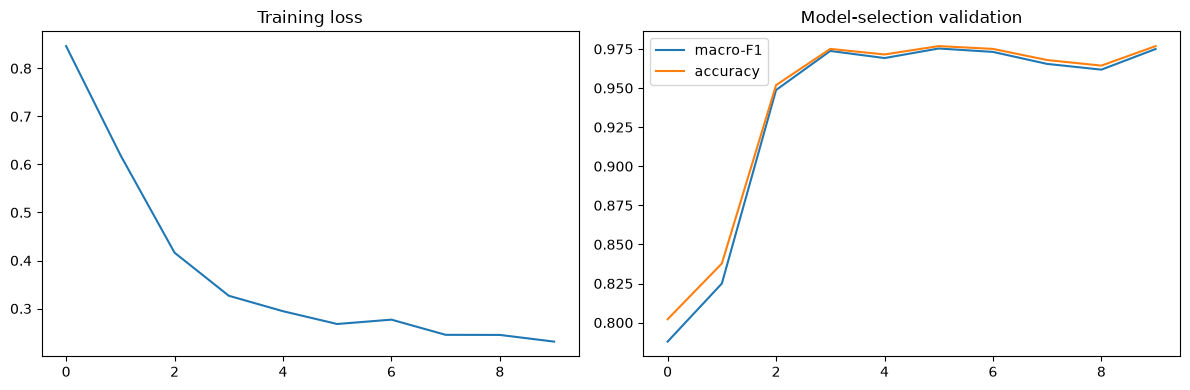

In [10]:
checkpoint_path = OUTPUT_DIR / "best_state_dict.pt"
history_path = ARTIFACT_DIR / "training_history.csv"
if checkpoint_path.exists() and history_path.exists():
    # A completed run can be recalibrated/evaluated without changing its
    # learned weights. This is useful when only the rejection policy changes.
    best_state = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(best_state)
    history = pd.read_csv(history_path)
    print("Loaded existing trained checkpoint; skipped weight training.")
else:
    history_head, best_f1, best_state = fit_stage(
        "head", HEAD_EPOCHS, HEAD_LR, HEAD_EPOCHS + 1
    )
    for parameter in model.features.parameters():
        parameter.requires_grad = True
    history_finetune, best_f1, best_state = fit_stage(
        "finetune",
        FINETUNE_EPOCHS,
        FINETUNE_LR,
        EARLY_STOPPING_PATIENCE,
        best_f1,
        best_state,
    )
    model.load_state_dict(best_state)
    history = pd.DataFrame(history_head + history_finetune)
display(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"])
axes[0].set_title("Training loss")
axes[1].plot(history["val_macro_f1"], label="macro-F1")
axes[1].plot(history["val_accuracy"], label="accuracy")
axes[1].legend()
axes[1].set_title("Model-selection validation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=160)
plt.show()


## 6. Dedicated calibration and OOD-aware threshold selection

Temperature and rejection thresholds are learned only from the calibration
partitions. The final field and OOD tests remain untouched.


In [11]:
cal_logits, cal_labels = collect_logits(model, loaders["calibration"])
ood_cal_logits, _ = collect_logits(model, loaders["ood_calibration"])

log_temperature = nn.Parameter(torch.zeros(1, device=DEVICE))
optimizer = torch.optim.LBFGS(
    [log_temperature], lr=0.05, max_iter=80, line_search_fn="strong_wolfe"
)
cal_logits_device = cal_logits.to(DEVICE)
cal_labels_device = cal_labels.to(DEVICE)

def calibration_closure():
    optimizer.zero_grad()
    temperature = log_temperature.exp().clamp(0.05, 10.0)
    loss = nn.functional.cross_entropy(cal_logits_device / temperature, cal_labels_device)
    loss.backward()
    return loss

before_nll = nn.functional.cross_entropy(cal_logits_device, cal_labels_device).item()
optimizer.step(calibration_closure)
TEMPERATURE = float(log_temperature.exp().clamp(0.05, 10.0).item())
after_nll = nn.functional.cross_entropy(
    cal_logits_device / TEMPERATURE, cal_labels_device
).item()
print(f"Temperature: {TEMPERATURE:.4f}; NLL {before_nll:.4f} -> {after_nll:.4f}")

def score_arrays(logits):
    probabilities = torch.softmax(logits / TEMPERATURE, dim=1).numpy()
    ordered = np.sort(probabilities, axis=1)
    confidence = ordered[:, -1]
    margin = ordered[:, -1] - ordered[:, -2]
    entropy = -(probabilities * np.log(np.clip(probabilities, 1e-12, 1))).sum(1)
    entropy /= math.log(probabilities.shape[1])
    prediction = probabilities.argmax(1)
    return probabilities, confidence, margin, entropy, prediction

_, cal_conf, cal_margin, cal_entropy, cal_pred = score_arrays(cal_logits)
_, ood_conf, ood_margin, ood_entropy, _ = score_arrays(ood_cal_logits)
cal_true = cal_labels.numpy()

rows = []
confidence_grid = np.unique(np.concatenate([
    np.arange(0.40, 0.98, 0.01),
    np.array([0.98, 0.985, 0.99, 0.9925, 0.995, 0.9975, 0.999]),
]))
for min_confidence in confidence_grid:
    for min_margin in np.arange(0.05, 0.96, 0.025):
        for max_entropy in np.arange(0.05, 0.91, 0.025):
            accepted = (
                (cal_conf >= min_confidence)
                & (cal_margin >= min_margin)
                & (cal_entropy <= max_entropy)
            )
            ood_accepted = (
                (ood_conf >= min_confidence)
                & (ood_margin >= min_margin)
                & (ood_entropy <= max_entropy)
            )
            coverage = float(accepted.mean())
            accuracy = float((cal_pred[accepted] == cal_true[accepted]).mean()) if accepted.any() else 0.0
            ood_far = float(ood_accepted.mean()) if len(ood_accepted) else 1.0
            rows.append({
                "min_confidence": round(float(min_confidence), 4),
                "min_margin": round(float(min_margin), 4),
                "max_normalized_entropy": round(float(max_entropy), 4),
                "coverage": coverage,
                "accepted_accuracy": accuracy,
                "ood_false_acceptance": ood_far,
            })

threshold_table = pd.DataFrame(rows)
eligible = threshold_table[
    (threshold_table.accepted_accuracy >= TARGET_ACCEPTED_ACCURACY)
    & (threshold_table.coverage >= MIN_COVERAGE)
    & (
        threshold_table.ood_false_acceptance
        <= CALIBRATION_MAX_OOD_FALSE_ACCEPTANCE
    )
]
if len(eligible):
    selected = eligible.sort_values(
        ["coverage", "ood_false_acceptance", "accepted_accuracy"],
        ascending=[False, True, False],
    ).iloc[0]
    threshold_reason = "met calibration accuracy, coverage, and OOD gates"
else:
    scored = threshold_table.assign(
        utility=lambda frame: (
            frame.accepted_accuracy
            + 0.35 * frame.coverage
            - 1.5 * frame.ood_false_acceptance
        )
    )
    selected = scored.sort_values("utility", ascending=False).iloc[0]
    threshold_reason = "no candidate met every gate; selected best evaluation candidate"

THRESHOLDS = {
    "min_confidence": float(selected.min_confidence),
    "min_margin": float(selected.min_margin),
    "max_normalized_entropy": float(selected.max_normalized_entropy),
    "unknown_max_confidence": round(max(0.30, float(selected.min_confidence) - 0.25), 2),
    "unknown_min_normalized_entropy": round(min(0.98, float(selected.max_normalized_entropy) + 0.20), 2),
}
print(threshold_reason)
print(json.dumps(THRESHOLDS, indent=2))
display(pd.DataFrame([selected]))


Temperature: 0.7918; NLL 0.1184 -> 0.1075


met calibration accuracy, coverage, and OOD gates
{
  "min_confidence": 0.985,
  "min_margin": 0.05,
  "max_normalized_entropy": 0.075,
  "unknown_max_confidence": 0.73,
  "unknown_min_normalized_entropy": 0.28
}


,min_confidence,min_margin,max_normalized_entropy,coverage,accepted_accuracy,ood_false_acceptance
76406,0.985,0.05,0.075,0.683274,0.994792,0.04848


## 7. Untouched internal, field, and OOD evaluation

PlantDoc contains no healthy maize test folder, while CD&S provides field GLS and
NLB but no rust or healthy class. Metrics are therefore reported for PlantDoc,
CD&S, and their combined external field set. Per-source recall gates apply only
to classes supported by that source. Confusion matrices still include every
model output, including incorrect predictions of the healthy class.


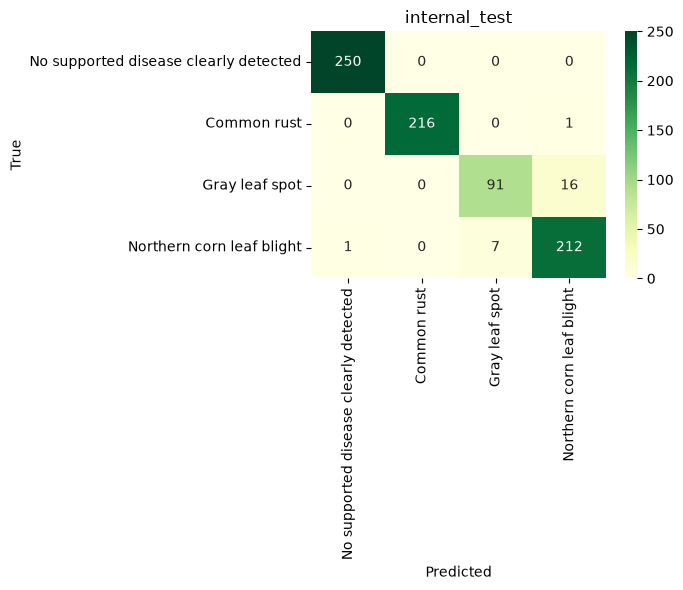

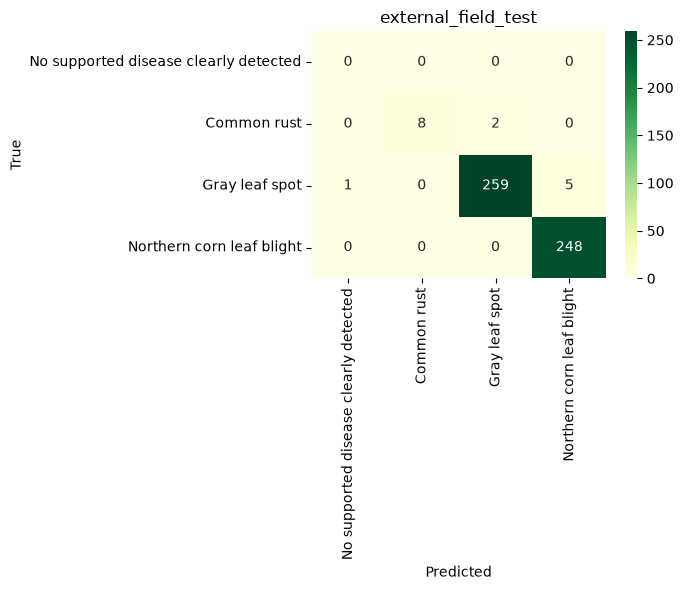

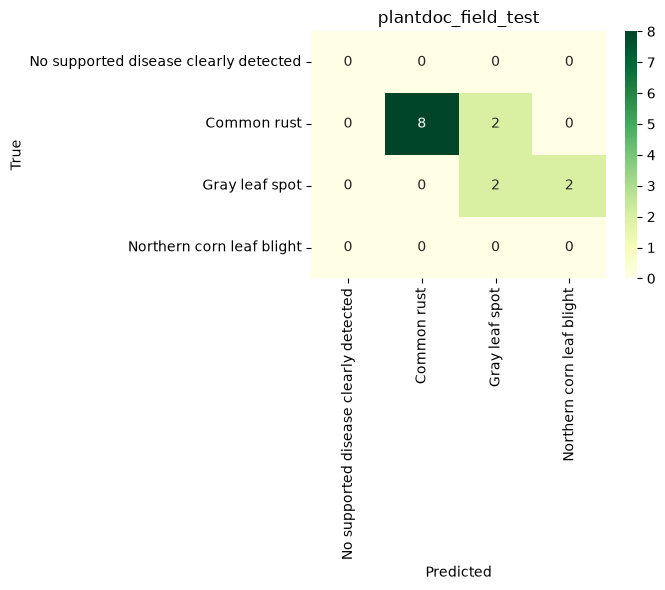

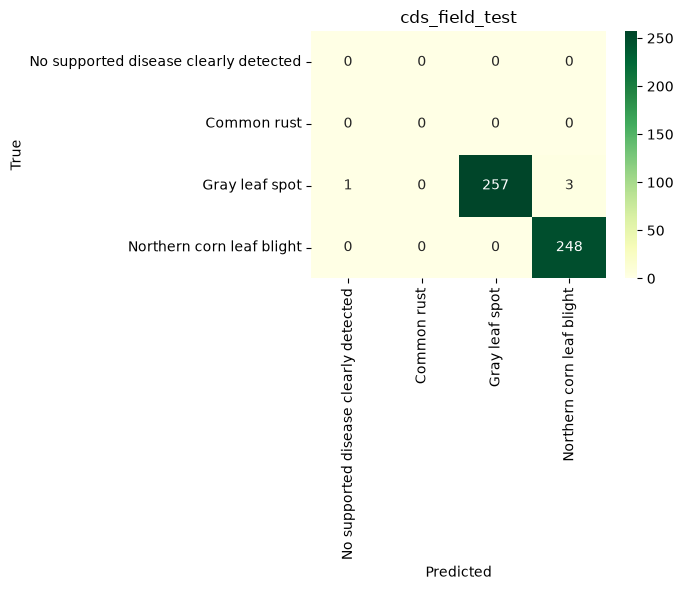

,dataset,samples,accuracy,macro_f1,ece,coverage,accepted_accuracy
0,internal_test,794,0.968514,0.956955,0.009576,0.638539,0.996055
1,external_field_test,523,0.984704,0.954567,0.006335,0.837476,0.997717
2,plantdoc_field_test,14,0.714286,0.694444,0.276617,0.571429,0.875000
3,cds_field_test,509,0.992141,0.993133,0.012043,0.844794,1.000000


OOD false-acceptance rate: 0.0863


In [12]:
def accepted_mask(confidence, margin, entropy):
    return (
        (confidence >= THRESHOLDS["min_confidence"])
        & (margin >= THRESHOLDS["min_margin"])
        & (entropy <= THRESHOLDS["max_normalized_entropy"])
    )

def expected_calibration_error(probabilities, labels, bins=10):
    confidence = probabilities.max(1)
    predictions = probabilities.argmax(1)
    edges = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for low, high in zip(edges[:-1], edges[1:]):
        selected = (confidence > low) & (confidence <= high)
        if selected.any():
            ece += selected.mean() * abs(
                (predictions[selected] == labels[selected]).mean()
                - confidence[selected].mean()
            )
    return float(ece)

def evaluate_known(name, loader):
    logits, labels = collect_logits(model, loader)
    probabilities, confidence, margin, entropy, predictions = score_arrays(logits)
    true = labels.numpy()
    accepted = accepted_mask(confidence, margin, entropy)
    supported_labels = sorted(set(true.tolist()))
    report = classification_report(
        true,
        predictions,
        labels=list(range(len(CLASS_NAMES))),
        target_names=[DISPLAY_NAMES[name] for name in CLASS_NAMES],
        zero_division=0,
        output_dict=True,
    )
    result = {
        "dataset": name,
        "samples": len(true),
        "accuracy": float(accuracy_score(true, predictions)),
        "macro_f1": float(
            f1_score(
                true,
                predictions,
                labels=supported_labels,
                average="macro",
                zero_division=0,
            )
        ),
        "ece": expected_calibration_error(probabilities, true),
        "coverage": float(accepted.mean()),
        "accepted_accuracy": (
            float((predictions[accepted] == true[accepted]).mean())
            if accepted.any() else 0.0
        ),
    }
    matrix = confusion_matrix(true, predictions, labels=list(range(len(CLASS_NAMES))))
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="YlGn",
        xticklabels=[DISPLAY_NAMES[x] for x in CLASS_NAMES],
        yticklabels=[DISPLAY_NAMES[x] for x in CLASS_NAMES],
    )
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name}_confusion_matrix.png", dpi=160)
    plt.show()
    return result, report, true, predictions

internal_result, internal_report, internal_true, internal_pred = evaluate_known(
    "internal_test", loaders["internal_test"]
)
external_result, external_report, external_true, external_pred = evaluate_known(
    "external_field_test", loaders["external_field_test"]
)
plantdoc_result, plantdoc_report, plantdoc_true, plantdoc_pred = evaluate_known(
    "plantdoc_field_test", loaders["plantdoc_field_test"]
)
cds_result, cds_report, cds_true, cds_pred = evaluate_known(
    "cds_field_test", loaders["cds_field_test"]
)
ood_test_logits, _ = collect_logits(model, loaders["ood_test"])
_, ood_conf, ood_margin, ood_entropy, _ = score_arrays(ood_test_logits)
OOD_FALSE_ACCEPTANCE = float(
    accepted_mask(ood_conf, ood_margin, ood_entropy).mean()
)
display(pd.DataFrame([
    internal_result,
    external_result,
    plantdoc_result,
    cds_result,
]))
print("OOD false-acceptance rate:", round(OOD_FALSE_ACCEPTANCE, 4))


In [13]:
def bootstrap_interval(true, predicted, metric, repeats=1000):
    rng = np.random.default_rng(SEED)
    values = []
    indices = np.arange(len(true))
    for _ in range(repeats):
        draw = rng.choice(indices, size=len(indices), replace=True)
        values.append(metric(true[draw], predicted[draw]))
    return {
        "estimate": float(metric(true, predicted)),
        "lower_95": float(np.percentile(values, 2.5)),
        "upper_95": float(np.percentile(values, 97.5)),
    }

internal_ci_labels = sorted(set(internal_true.tolist()))
external_ci_labels = sorted(set(external_true.tolist()))
plantdoc_ci_labels = sorted(set(plantdoc_true.tolist()))
cds_ci_labels = sorted(set(cds_true.tolist()))
confidence_intervals = {
    "internal_accuracy": bootstrap_interval(internal_true, internal_pred, accuracy_score),
    "internal_macro_f1": bootstrap_interval(
        internal_true, internal_pred, lambda y, p: f1_score(
            y, p, labels=internal_ci_labels, average="macro", zero_division=0
        )
    ),
    "external_accuracy": bootstrap_interval(external_true, external_pred, accuracy_score),
    "external_macro_f1": bootstrap_interval(
        external_true, external_pred, lambda y, p: f1_score(
            y, p, labels=external_ci_labels, average="macro", zero_division=0
        )
    ),
    "plantdoc_macro_f1": bootstrap_interval(
        plantdoc_true, plantdoc_pred, lambda y, p: f1_score(
            y, p, labels=plantdoc_ci_labels, average="macro", zero_division=0
        )
    ),
    "cds_macro_f1": bootstrap_interval(
        cds_true, cds_pred, lambda y, p: f1_score(
            y, p, labels=cds_ci_labels, average="macro", zero_division=0
        )
    ),
}
display(pd.DataFrame(confidence_intervals).T)


,estimate,lower_95,upper_95
internal_accuracy,0.968514,0.955919,0.981108
internal_macro_f1,0.956955,0.938568,0.973912
external_accuracy,0.984704,0.975143,0.994264
external_macro_f1,0.954567,0.889990,0.996085
plantdoc_macro_f1,0.694444,0.409091,0.918129
cds_macro_f1,0.993133,0.985251,0.999037


## 8. Deployment gates

Passing a clean internal test is not enough. The combined external field,
official CD&S field, calibration, OOD, leakage, and export-equivalence gates all
contribute to the final decision. PlantDoc is retained as a transparent
challenge audit, but its 14 supported test images are too few to act as an
independent deployment gate. Its results remain in metadata and the model card.


In [14]:
external_supported_labels = sorted(set(external_true.tolist()))
external_recalls = recall_score(
    external_true,
    external_pred,
    labels=external_supported_labels,
    average=None,
    zero_division=0,
)
plantdoc_recalls = recall_score(
    plantdoc_true,
    plantdoc_pred,
    labels=sorted(set(plantdoc_true.tolist())),
    average=None,
    zero_division=0,
)
cds_recalls = recall_score(
    cds_true,
    cds_pred,
    labels=sorted(set(cds_true.tolist())),
    average=None,
    zero_division=0,
)
GATES = {
    "external_macro_f1_at_least_0_80": external_result["macro_f1"] >= 0.80,
    "cds_macro_f1_at_least_0_80": cds_result["macro_f1"] >= 0.80,
    "supported_class_recall_at_least_0_70": bool(np.all(external_recalls >= 0.70)),
    "cds_class_recall_at_least_0_70": bool(np.all(cds_recalls >= 0.70)),
    "accepted_external_accuracy_at_least_0_90": external_result["accepted_accuracy"] >= 0.90,
    "accepted_external_coverage_at_least_0_30": external_result["coverage"] >= 0.30,
    "ood_false_acceptance_at_most_0_10": OOD_FALSE_ACCEPTANCE <= 0.10,
    "external_ece_at_most_0_08": external_result["ece"] <= 0.08,
    "cds_ece_at_most_0_10": cds_result["ece"] <= 0.10,
    "no_cross_partition_hash_leakage": len(leaks) == 0,
    "external_sample_count_at_least_20": len(external_true) >= 20,
}
ADVISORY_AUDITS = {
    "plantdoc_supported_samples": int(plantdoc_result["samples"]),
    "plantdoc_advisory_only_because_supported_samples_below_20": (
        plantdoc_result["samples"] < 20
    ),
    "plantdoc_accepted_accuracy": float(plantdoc_result["accepted_accuracy"]),
    "plantdoc_accepted_coverage": float(plantdoc_result["coverage"]),
}
DEPLOYMENT_READY_BEFORE_EXPORT = all(GATES.values())
display(pd.DataFrame(
    [{"gate": key, "passed": value} for key, value in GATES.items()]
))
print("Deployment-ready before export test:", DEPLOYMENT_READY_BEFORE_EXPORT)


,gate,passed
0,external_macro_f1_at_least_0_80,True
1,cds_macro_f1_at_least_0_80,True
2,supported_class_recall_at_least_0_70,True
3,cds_class_recall_at_least_0_70,True
4,accepted_external_accuracy_at_least_0_90,True
5,accepted_external_coverage_at_least_0_30,True
6,ood_false_acceptance_at_most_0_10,True
7,external_ece_at_most_0_08,True
8,cds_ece_at_most_0_10,True
9,no_cross_partition_hash_leakage,True


Deployment-ready before export test: True


## 9. Single-image response-contract preview

This preview shows the structured evidence consumed by the Flask backend. A
probability is never presented as a confirmed field diagnosis.


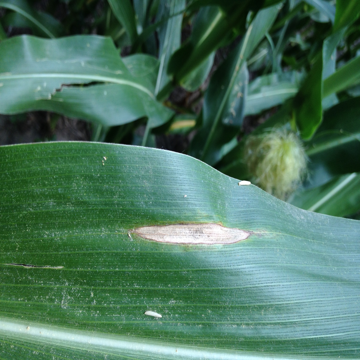

{
  "status": "uncertain",
  "condition_code": "northern_leaf_blight",
  "confidence": 0.9674000144004822,
  "margin": 0.9468136429786682,
  "normalized_entropy": 0.12508897483348846,
  "probabilities": {
    "healthy": 0.02058635838329792,
    "common_rust": 0.0064985365606844425,
    "gray_leaf_spot": 0.005515144672244787,
    "northern_leaf_blight": 0.9674000144004822
  }
}


In [15]:
def predict_pil(image):
    model.eval()
    tensor = eval_transform(ImageOps.exif_transpose(image).convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.inference_mode():
        logits = model(tensor).float().cpu()
    probabilities, confidence, margin, entropy, prediction = score_arrays(logits)
    accepted = bool(accepted_mask(confidence, margin, entropy)[0])
    index = int(prediction[0])
    return {
        "status": "supported" if accepted else "uncertain",
        "condition_code": CLASS_NAMES[index],
        "confidence": float(confidence[0]),
        "margin": float(margin[0]),
        "normalized_entropy": float(entropy[0]),
        "probabilities": {
            name: float(probabilities[0, i]) for i, name in enumerate(CLASS_NAMES)
        },
    }

if external_test_samples:
    example_path = external_test_samples[0][0]
    with Image.open(example_path) as example:
        display(example.copy().resize((360, 360)))
        print(json.dumps(predict_pil(example), indent=2))


## 10. Export, equivalence test, metadata, model card, and ZIP

Copy the exported disease folder into `backend/models/disease/`. The class order,
normalization, calibration, thresholds, model version, dataset revisions, quality
gates, and checksums travel with the model.


In [16]:
model_cpu = copy.deepcopy(model).cpu().eval()
example_input = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
with torch.inference_mode():
    eager_output = model_cpu(example_input)
traced = torch.jit.trace(model_cpu, example_input)
with torch.inference_mode():
    traced_output = traced(example_input)
MAX_EXPORT_DIFFERENCE = float((eager_output - traced_output).abs().max().item())
EXPORT_EQUIVALENT = MAX_EXPORT_DIFFERENCE <= 1e-5
GATES["torchscript_equivalence"] = EXPORT_EQUIVALENT
DEPLOYMENT_READY = all(GATES.values())

model_version = time.strftime("maize-disease-%Y%m%d-%H%M%S")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
model_path = ARTIFACT_DIR / "maize_disease.torchscript.pt"
# PyTorch's Windows C++ path overload can reject otherwise valid Unicode paths.
# Opening the file in Python first keeps Chinese workspace/user names portable.
with open(model_path, "wb") as model_file:
    torch.jit.save(traced, model_file)

metadata = {
    "artifact_schema_version": "1.0",
    "model_version": model_version,
    "deployment_ready": DEPLOYMENT_READY,
    "architecture": architecture,
    "profile": PROFILE,
    "classes": CLASS_NAMES,
    "display_names": DISPLAY_NAMES,
    "image_size": IMAGE_SIZE,
    "resize_size": 256,
    "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
    "temperature": TEMPERATURE,
    "thresholds": THRESHOLDS,
    "gates": GATES,
    "advisory_audits": ADVISORY_AUDITS,
    "metrics": {
        "internal": internal_result,
        "external_field": external_result,
        "plantdoc_field": plantdoc_result,
        "cds_field": cds_result,
        "ood_false_acceptance": OOD_FALSE_ACCEPTANCE,
        "confidence_intervals": confidence_intervals,
    },
    "data": {
        "plantvillage": {
            "url": PLANTVILLAGE_URL,
            "revision": PLANTVILLAGE_REVISION,
            "split_revision": PLANTVILLAGE_SPLIT_REVISION,
        },
        "plantdoc": {
            "url": PLANTDOC_URL,
            "revision": PLANTDOC_REVISION,
            "license": "CC BY 4.0",
            "windows_safe_file_map": (
                PLANTDOC_FILE_MAP.name if PLANTDOC_FILE_MAP else None
            ),
        },
        "cds": {
            "url": CDS_URL,
            "osf_node": CDS_OSF_NODE,
            "subset": "Dataset_Original",
            "official_split": True,
            "license": "Not specified in OSF metadata; verify before redistribution",
            "manifest": "cds_manifest.json",
        },
        "partition_manifest": manifest_path.name,
        "leakage_removals": leakage_report_path.name,
        "development_duplicates_removed": len(removal_paths),
    },
    "versions": {
        "python": sys.version.split()[0],
        "torch": torch.__version__,
        "torchvision": __import__("torchvision").__version__,
        "sklearn": sklearn.__version__,
    },
    "export": {
        "format": "torchscript",
        "max_eager_difference": MAX_EXPORT_DIFFERENCE,
    },
}
metadata_path = ARTIFACT_DIR / "metadata.json"
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
shutil.copy2(manifest_path, ARTIFACT_DIR / manifest_path.name)
shutil.copy2(leakage_report_path, ARTIFACT_DIR / leakage_report_path.name)
if PLANTDOC_FILE_MAP and PLANTDOC_FILE_MAP.exists():
    shutil.copy2(PLANTDOC_FILE_MAP, ARTIFACT_DIR / PLANTDOC_FILE_MAP.name)
shutil.copy2(CDS_MANIFEST, ARTIFACT_DIR / "cds_manifest.json")
history.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)

model_card = f'''# Maize Leaf Disease Assistant Model Card

## Intended use

Image-assisted screening for four maize leaf conditions. This model is not a
confirmed field diagnosis and must not prescribe pesticide products or dosage.

## Status

- Model version: `{model_version}`
- Architecture: `{architecture}`
- Deployment ready: **{DEPLOYMENT_READY}**
- External field samples: {external_result['samples']}
- External field macro-F1: {external_result['macro_f1']:.4f}
- PlantDoc field macro-F1: {plantdoc_result['macro_f1']:.4f}
- PlantDoc supported images: {plantdoc_result['samples']} (advisory audit only)
- PlantDoc accepted accuracy: {plantdoc_result['accepted_accuracy']:.4f}
- PlantDoc accepted coverage: {plantdoc_result['coverage']:.4f}
- CD&S field macro-F1: {cds_result['macro_f1']:.4f}
- Accepted external accuracy: {external_result['accepted_accuracy']:.4f}
- Accepted external coverage: {external_result['coverage']:.4f}
- OOD false-acceptance rate: {OOD_FALSE_ACCEPTANCE:.4f}

## Important limitations

- PlantDoc contributes only {plantdoc_result['samples']} unambiguous supported
  test images, so it is disclosed as an advisory challenge audit rather than an
  independent deployment gate.
- The public external maize test sources have no healthy maize field class.
- CD&S field images were collected at a Purdue research site; PlantDoc images
  were web-sourced. Neither source substitutes for project-region field data.
- Performance may change by country, hybrid, growth stage, camera, weather, and
  farming practice.
- Unsupported diseases, insect damage, nutrient stress, and chemical injury can
  resemble supported classes.
- Continue collecting independent, labelled project field images and retain
  agronomist review decisions for future evaluation.

## Quality gates

```json
{json.dumps(GATES, indent=2)}
```

## Advisory audits

```json
{json.dumps(ADVISORY_AUDITS, indent=2)}
```
'''
(ARTIFACT_DIR / "MODEL_CARD.md").write_text(model_card, encoding="utf-8")

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

checksums = {
    path.name: file_hash(path)
    for path in ARTIFACT_DIR.iterdir()
    if path.is_file() and path.name != "SHA256SUMS.json"
}
(ARTIFACT_DIR / "SHA256SUMS.json").write_text(
    json.dumps(checksums, indent=2), encoding="utf-8"
)
archive_path = Path(shutil.make_archive(
    str(OUTPUT_DIR / "maize_disease_model_artifacts"),
    "zip",
    root_dir=ARTIFACT_DIR,
))
print("Deployment ready:", DEPLOYMENT_READY)
print("Artifact archive:", archive_path)
print("Copy extracted files to: backend/models/disease/")


Deployment ready: True
Artifact archive: C:\Users\张嘉璐\Documents\Codex\2026-07-24\new-chat\work\training_run\maize_disease_agronomist\outputs\maize_disease_model_artifacts.zip
Copy extracted files to: backend/models/disease/


## 11. What to keep and what to do next

Keep:

- `maize_disease_model_artifacts.zip`
- `maize_disease.torchscript.pt`
- `metadata.json`
- `MODEL_CARD.md`
- `SHA256SUMS.json`
- partition manifest, training history, plots, and this executed Notebook

Before describing the module as field-ready, add an independent project-owned
test set with examples from different fields, phones, hybrids, growth stages,
lighting, healthy plants, other diseases, insect damage, nutrient stress, and
poor-quality images. Review corrections collected by the Agronomist Dashboard
should inform the next dataset version, but must not leak into the current test
set.
